In [55]:
import pandas as pd
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [56]:
reviews = pd.read_csv('../Data/processed/reviews_clean.csv')
items = pd.read_csv('../Data/raw/20190928-items.csv')
items = items[['asin','brand','title']]

In [57]:
reviews.head()

,verified,title,body,brand,name_pro,clean_text,clean_title
0,False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,awhile absolute doo doo read review detect rag...,def not best but not worst
1,False,Text Messaging Does not Work,Due to a software issue between Nokia and Spri...,Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,due software issue sprint text messaging capab...,text messaging doe not work
2,False,Love This Phone,"This is a great, reliable phone. I also purcha...",Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,great reliable also purchased died menu easily...,love this phone
3,False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,love really need one expect price bill receive...,love the phone but
4,False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,great every purpose offer except day bought it...,great phone service and option lousy case


In [58]:
reviews.isnull().sum()

verified       0
title          0
body           0
brand          0
name_pro       0
clean_text     0
clean_title    0
dtype: int64

In [59]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

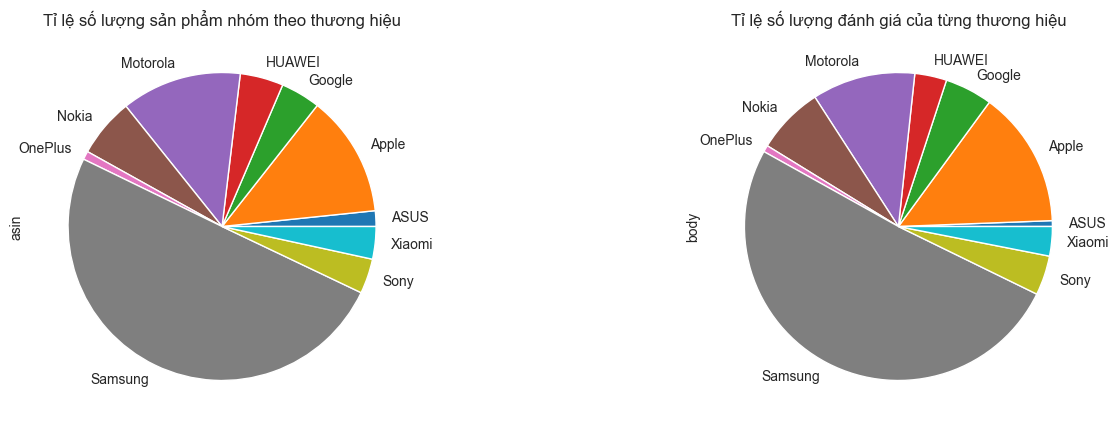

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
items.groupby("brand").count()["asin"].plot(kind="pie", ax=axes[0], title="Tỉ lệ số lượng sản phẩm nhóm theo thương hiệu")
reviews.groupby("brand").count()["body"].plot(kind="pie", ax=axes[1], title="Tỉ lệ số lượng đánh giá của từng thương hiệu")
plt.show()


***1. Có bao nhiêu phần trăm đánh giá là từ những khách hàng đã mua sản phẩm mà họ đánh giá tại Amazon?***


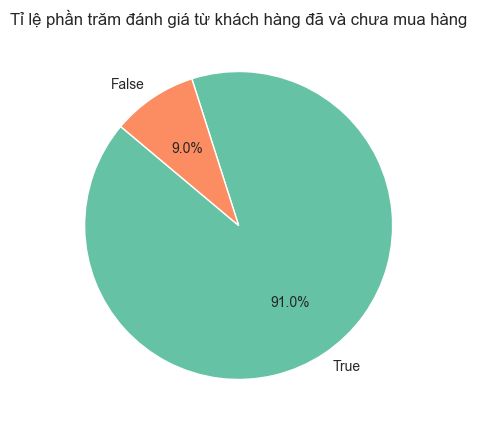

In [61]:
verified_counts = reviews['verified'].value_counts()
sns.set_style("whitegrid")
plt.figure(figsize=(5, 5))
plt.pie(verified_counts, labels=verified_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"), wedgeprops={'edgecolor': 'white'})
plt.title("Tỉ lệ phần trăm đánh giá từ khách hàng đã và chưa mua hàng")
plt.show()

> 91% đánh giá là từ những khách hàng được xác nhận đã mua sản phẩm mà họ thực hiện đánh giá.

***2. Những cụm từ xuất hiện nhiều nhất trong các đánh giá là cụm từ nào? Những cụm từ đó thể hiện sự quan tâm đến vấn đề nào từ khách hàng?***


<Axes: >

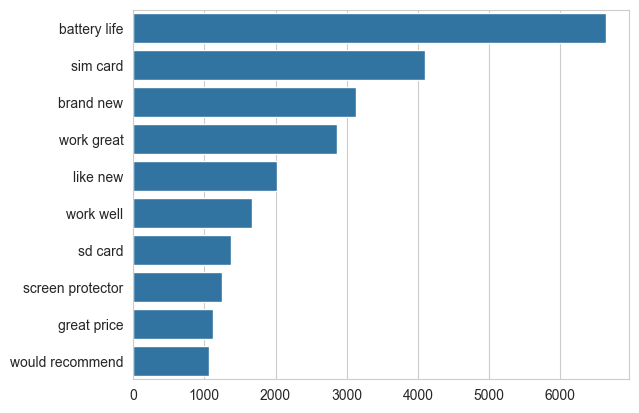

In [62]:
top_bi_grams=get_top_ngram(reviews['clean_text'],n=2)
x,y=map(list,zip(*top_bi_grams))
sns.barplot(x=y,y=x)

> Cụm từ được quan tâm nhiều nhất là "battery life", tiếp đến là "sim card", "brand new" và "work great".
* Có vẻ khách hàng quan tâm nhiều đến vấn đề ở linh kiện của những chiếc điện thoại đặc biệt là tuổi thọ của pin, tiếp đến là về những thương hiệu mới và những lời khen cho hiệu năng, giá cả.


In [63]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ducdu\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [64]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

In [65]:
reviews['body_score'] = reviews['clean_text'].apply(lambda x: sid.polarity_scores(x))

reviews['tile_score'] = reviews['clean_title'].apply(lambda x: sid.polarity_scores(x))

In [66]:
reviews['polarity'] = reviews['body_score'].apply(lambda x: x['compound'])
reviews.drop('body_score', axis=1, inplace=True)

reviews['title_polarity'] = reviews['tile_score'].apply(lambda x: x['compound'])
reviews.drop('tile_score', axis=1, inplace=True)

In [67]:
reviews.head()

,verified,title,body,brand,name_pro,clean_text,clean_title,polarity,title_polarity
0,False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,awhile absolute doo doo read review detect rag...,def not best but not worst,0.8655,0.5035
1,False,Text Messaging Does not Work,Due to a software issue between Nokia and Spri...,Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,due software issue sprint text messaging capab...,text messaging doe not work,0.8625,0.0000
2,False,Love This Phone,"This is a great, reliable phone. I also purcha...",Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,great reliable also purchased died menu easily...,love this phone,0.8779,0.6369
3,False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,love really need one expect price bill receive...,love the phone but,0.9136,0.3818
4,False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,Nokia,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,great every purpose offer except day bought it...,great phone service and option lousy case,0.8850,0.1531


***3. Thương hiệu nào được đánh giá cao nhất, tích cực nhất?***

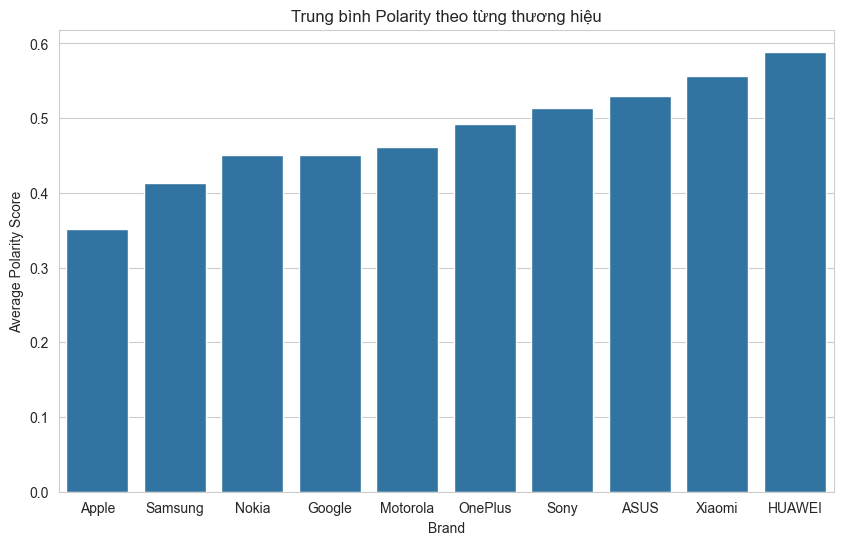

In [68]:
polarity_by_brand = reviews.groupby('brand')['polarity'].mean().reset_index()
polarity_by_brand = polarity_by_brand.sort_values(by='polarity')
plt.figure(figsize=(10, 6))
sns.barplot(x='brand', y='polarity', data=polarity_by_brand)
plt.title('Trung bình Polarity theo từng thương hiệu')
plt.xlabel('Brand')
plt.ylabel('Average Polarity Score')
plt.show()

>HUAWEI có đánh giá cao nhất/ tích cực nhất trong các thương hiệu.
* Vì vậy tiếp theo chúng ta sẽ chọn ra 3 thương hiệu để phân tích tiếp, trong đó 2 thương hiệu có nhiều đánh giá nhất đó là Samsung và Apple, 1 thương hiệu còn lại là HUAWEI.




***3. Độ dài của các đánh giá tập trung ở khoảng nào?***

***4. Độ dài đánh giá ảnh có ảnh hưởng gì đến độ tích cực và tiêu cực của đánh giá không?***

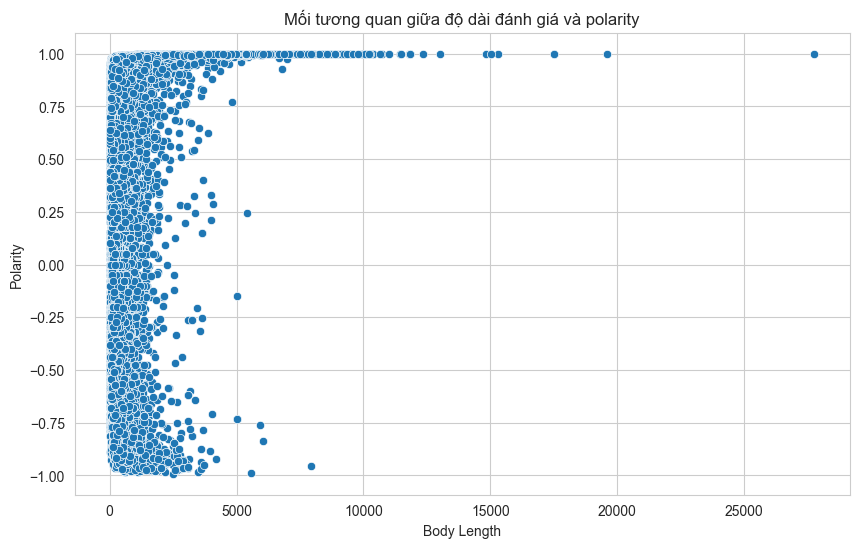

In [69]:
reviews['body_length'] = reviews['body'].apply(len)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='body_length', y='polarity', data=reviews)
plt.title('Mối tương quan giữa độ dài đánh giá và polarity')
plt.xlabel('Body Length')
plt.ylabel('Polarity')
plt.show()



> Độ dài đánh giá thường tập trung ở khoảng 0 đến 5000 ký tự.

>Có mối tương quan giữa độ dài của đánh giá và giá trị polarity nhưng rất yếu. Các đánh giá có phần dài hơn thường mang tính chất tích cực hơn.



***5. Sự phân phối của polarity của đánh giá có thay đổi giữa các đánh giá được xác minh và không được xác minh không?***

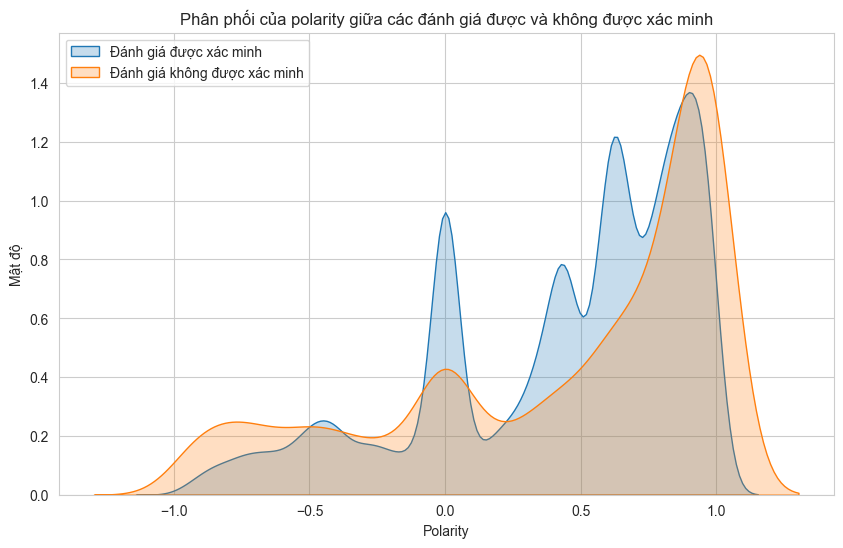

In [70]:
verified_reviews = reviews[reviews['verified'] == True]
unverified_reviews = reviews[reviews['verified'] == False]

verified_polarity = verified_reviews['polarity'].dropna()
unverified_polarity = unverified_reviews['polarity'].dropna()

plt.figure(figsize=(10, 6))
sns.kdeplot(verified_polarity, label='Đánh giá được xác minh', fill=True)
sns.kdeplot(unverified_polarity, label='Đánh giá không được xác minh', fill=True)
plt.title('Phân phối của polarity giữa các đánh giá được và không được xác minh')
plt.xlabel('Polarity')
plt.ylabel('Mật độ')
plt.legend(loc='upper left')
plt.show()


> Sự phân phối của polarity của các đánh giá có sự khác biệt giữa hai nhóm được xác minh và không được xác minh. Các đánh giá được xác minh thường tích cực và tập trung hơn, trong khi các đánh giá không được xác minh có xu hướng phân tán hơn về mức độ tích cực/tiêu cực.

***6. Liệu họ có xu hướng viết tiêu đề tích cực/tiêu cực trước để gây ấn tượng ban đầu hay không?***

In [71]:
reviews['title_sentiment'] = np.where(reviews['title_polarity'] >0, 'positive',
                                      np.where(reviews['title_polarity'] <0, 'negative', 'neutral'))

reviews['body_sentiment'] = np.where(reviews['polarity'] >0, 'positive',
                                     np.where(reviews['polarity'] <0, 'negative', 'neutral'))

reviews['sentiment_match'] = np.where(reviews['title_sentiment'] == reviews['body_sentiment'], True, False)

print("Khi tiêu đề và đánh giá cùng cảm xúc:")
print(reviews[reviews['sentiment_match'] == True]['title_sentiment'].value_counts(normalize=True))

print("\nKhi tiêu đề và đánh giá khác cảm xúc:")
print(reviews[reviews['sentiment_match'] == False]['title_sentiment'].value_counts(normalize=True))

Khi tiêu đề và đánh giá cùng cảm xúc:
title_sentiment
positive    0.760921
neutral     0.127681
negative    0.111398
Name: proportion, dtype: float64

Khi tiêu đề và đánh giá khác cảm xúc:
title_sentiment
neutral     0.721616
negative    0.166619
positive    0.111765
Name: proportion, dtype: float64


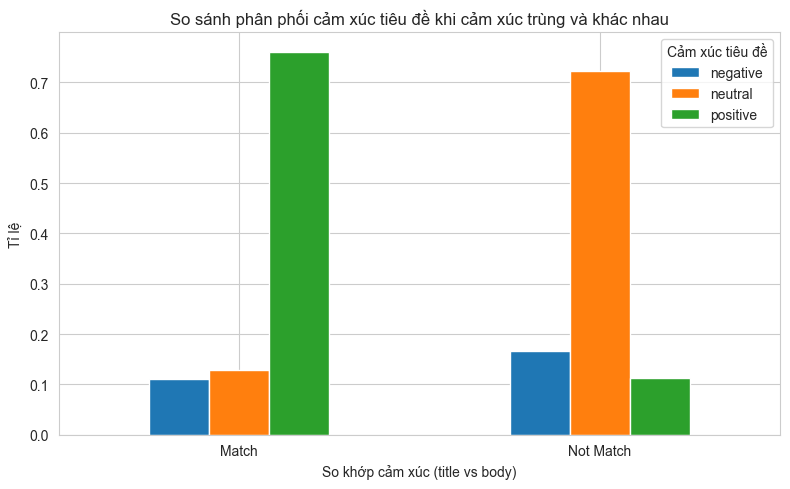

In [72]:
match_counts = reviews[reviews['sentiment_match'] == True]['title_sentiment'].value_counts(normalize=True)
not_match_counts = reviews[reviews['sentiment_match'] == False]['title_sentiment'].value_counts(normalize=True)


df_plot = pd.DataFrame({
    'Match': match_counts,
    'Not Match': not_match_counts
}).T 

df_plot.plot(kind='bar', figsize=(8, 5))
plt.title('So sánh phân phối cảm xúc tiêu đề khi cảm xúc trùng và khác nhau')
plt.xlabel('So khớp cảm xúc (title vs body)')
plt.ylabel('Tỉ lệ')
plt.xticks(rotation=0)
plt.legend(title='Cảm xúc tiêu đề')
plt.tight_layout()
plt.show()


> Ta có thể thấy xu hướng chung là khách hàng thường viết tiêu đề tích cực hơn khi họ nhất quán về cảm xúc trong cả tiêu đề và nội dung, có thể để gây ấn tượng ban đầu. Tuy nhiên, khi có sự khác biệt về cảm xúc, khách hàng có xu hướng viết tiêu đề trung tính hoặc một tỷ lệ nhỏ viết tiêu đề tiêu cực để gây ấn tượng ban đầu.

In [73]:
review_pos = reviews[reviews["polarity"] > 0]
review_neg = reviews[reviews["polarity"] < 0]

In [74]:
apple_review_pos = review_pos[review_pos["brand"] == "Apple"]
apple_review_neg = review_neg[review_neg["brand"] == "Apple"]

samsung_review_pos = review_pos[review_pos["brand"] == "Samsung"]
samsung_review_neg = review_neg[review_neg["brand"] == "Samsung"]

huawei_review_pos = review_pos[review_pos["brand"] == "HUAWEI"]
huawei_review_neg = review_neg[review_neg["brand"] == "HUAWEI"]

In [75]:
def process_reviews(reviews_pos_df, reviews_neg_df):
    grouped_reviews_pos = reviews_pos_df[['name_pro', 'clean_text']].groupby(by='name_pro').agg(lambda x: ' '.join(x))
    cv = CountVectorizer(analyzer='word')
    data_pos = cv.fit_transform(grouped_reviews_pos['clean_text'])
    dtm_pos = pd.DataFrame(data_pos.toarray(), columns=cv.get_feature_names_out())
    dtm_pos.index = grouped_reviews_pos.index

    grouped_reviews_neg = reviews_neg_df[['name_pro', 'clean_text']].groupby(by='name_pro').agg(lambda x: ' '.join(x))
    cv = CountVectorizer(analyzer='word')
    data_neg = cv.fit_transform(grouped_reviews_neg['clean_text'])
    dtm_neg = pd.DataFrame(data_neg.toarray(), columns=cv.get_feature_names_out())
    dtm_neg.index = grouped_reviews_neg.index

    return dtm_pos, dtm_neg

apple_pos_dtm, apple_neg_dtm = process_reviews(apple_review_pos, apple_review_neg)
samsung_pos_dtm, samsung_neg_dtm = process_reviews(samsung_review_pos, samsung_review_neg)
huawei_pos_dtm, huawei_neg_dtm = process_reviews(huawei_review_pos, huawei_review_neg)

In [76]:
review_grouped=reviews[['brand','clean_text']].groupby(by='brand').agg(lambda x:' '.join(x))
cv=CountVectorizer(analyzer='word')
data=cv.fit_transform(review_grouped['clean_text'])
review_dtm = pd.DataFrame(data.toarray(), columns=cv.get_feature_names_out())
review_dtm.index=review_grouped.index

In [77]:
from wordcloud import WordCloud

#hàm vẽ wordcloud theo brand
def draw_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis("off")
    plt.show()

#hàm vẽ worldcloud pos và neg
def plot_wordcloud(dtm, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dtm.sum())
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

#hàm sẽ biểu đồ tần số
def topn_wordfreq_bar_both(pos_dtm, neg_dtm, pos_num_doc, neg_num_doc, topn, title, palette, height=6, aspect=2):
    pos_freq = pos_dtm.sum(axis=0)
    neg_freq = neg_dtm.sum(axis=0)
    
    df_pos = pd.DataFrame(pos_freq, columns=["frequency"]).sort_values(by="frequency", ascending=False).head(topn)
    df_pos["frequency"] = df_pos["frequency"] / pos_num_doc
    df_pos["label"] = "Positive"
    
    df_neg = pd.DataFrame(neg_freq, columns=["frequency"]).sort_values(by="frequency", ascending=False).head(topn)
    df_neg["frequency"] = df_neg["frequency"] / neg_num_doc
    df_neg["label"] = "Negative"
    
    df_append = pd.concat([df_pos, df_neg], ignore_index=False)
    df_append.reset_index(inplace=True)
    
    sns.catplot(x="index", y="frequency", hue="label", data=df_append,
                kind="bar",
                palette=palette,
                height=height, aspect=aspect,
                legend_out=False)
    
    plt.title(title)
    plt.xlabel("Word")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha='right')
    plt.show()

***7. Yếu tố nào (thiết kế, hiệu năng, camera, pin, giá cả, v.v.) được nhắc đến nhiều nhất trong đánh giá của mỗi thương hiệu?***

***8. Có sự khác biệt nào giữa các đánh giá tích cực và tiêu cực của từng thương hiệu không?***

***9. Những từ khóa xuất hiện phổ biến ở các đánh giá tích cực có thể mang ý nghĩa cụ thể nào không?***

***10. Từ khóa nào xuất hiện nhiều nhất trong các đánh giá tiêu cực của cả ba thương hiệu?***

***11. Có từ khóa nào xuất hiện ở cả hai loại đánh giá nhưng có tần suất tiêu cực lớn hơn nhiều của mỗi thương hiệu không? Liệu có thể dự đoán các vấn đề tiềm ẩn cho các sản phẩm mới không?***

Những từ khóa nào xuất hiện nhiều nhất trong các đánh giá của khác hàng đối với thương hiệu Apple? Từ đó có thể suy ra những chủ đề/đặc điểm chính gì được nhắc đến trong đánh giá?


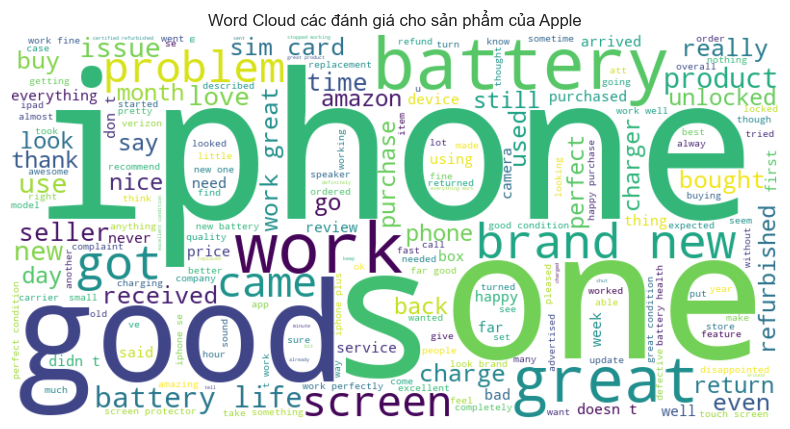

In [78]:
apple_reviews = review_grouped.loc["Apple", "clean_text"]
draw_wordcloud(apple_reviews, "Word Cloud các đánh giá cho sản phẩm của Apple")

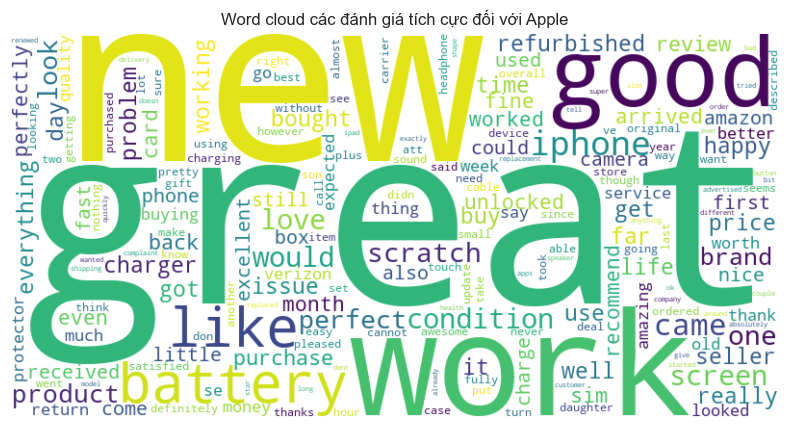

In [79]:
plot_wordcloud(apple_pos_dtm, 'Word cloud các đánh giá tích cực đối với Apple')

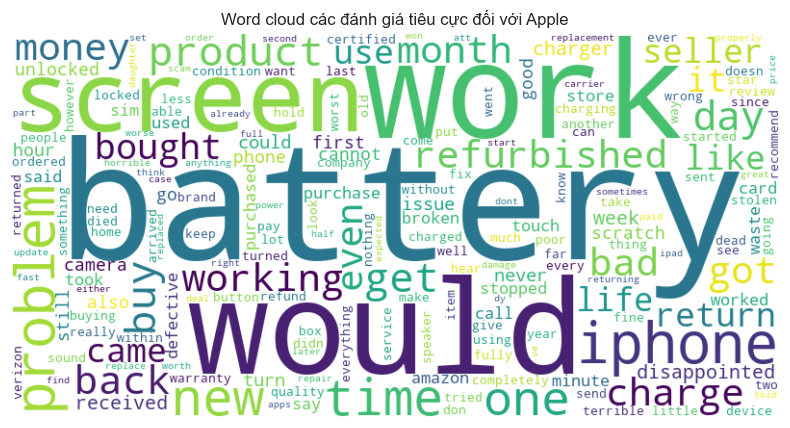

In [80]:
plot_wordcloud(apple_neg_dtm, 'Word cloud các đánh giá tiêu cực đối với Apple')

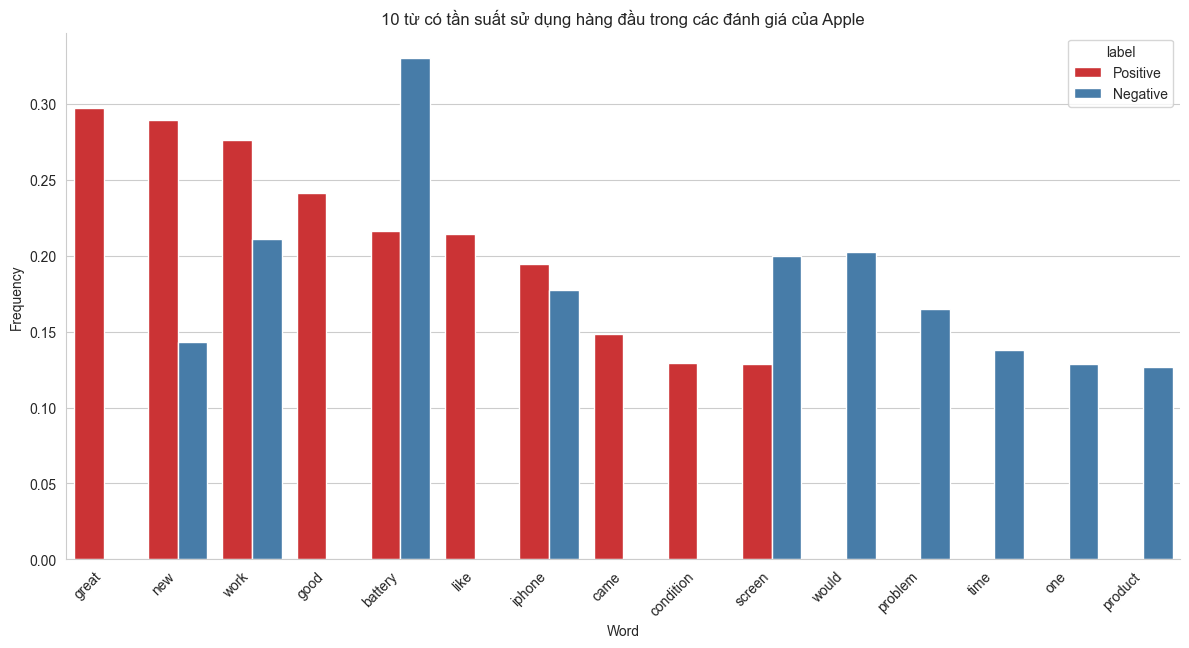

In [81]:
topn_wordfreq_bar_both(apple_pos_dtm, apple_neg_dtm, len(apple_review_pos), len(apple_review_neg), 10, "10 từ có tần suất sử dụng hàng đầu trong các đánh giá của Apple", "Set1")

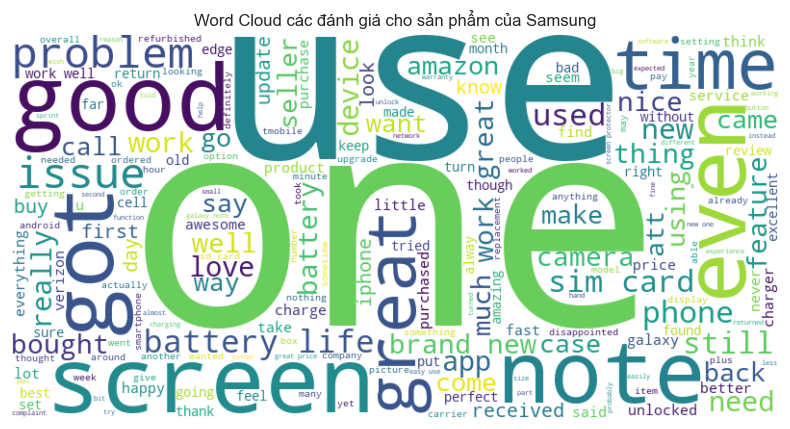

In [82]:
samsung_reviews = review_grouped.loc["Samsung", "clean_text"]
draw_wordcloud(samsung_reviews, "Word Cloud các đánh giá cho sản phẩm của Samsung")

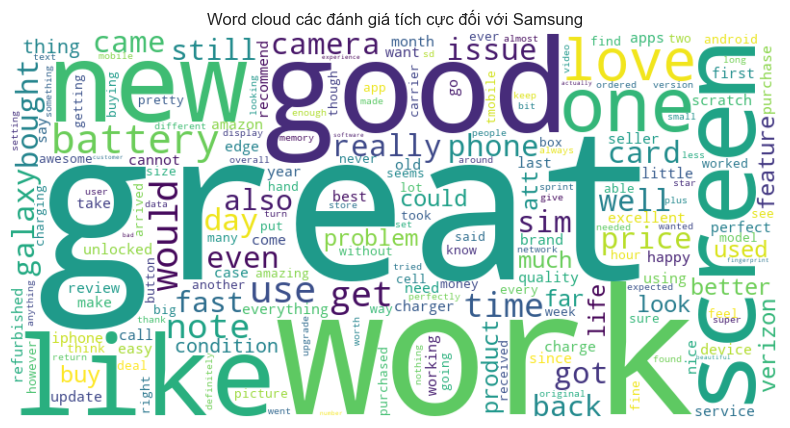

In [83]:
plot_wordcloud(samsung_pos_dtm, 'Word cloud các đánh giá tích cực đối với Samsung')

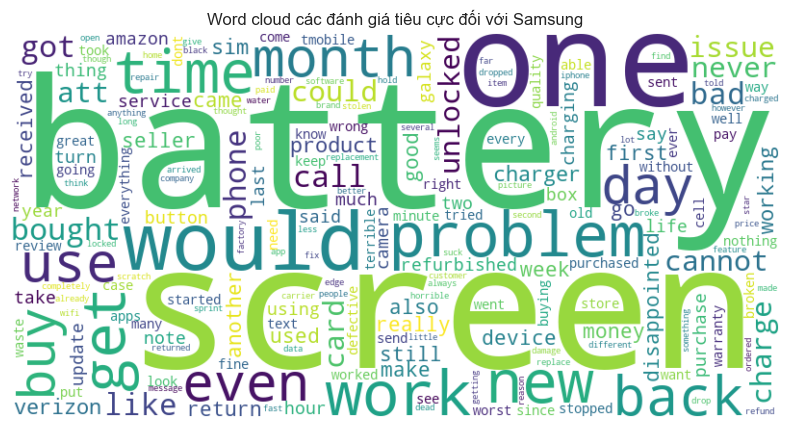

In [84]:
plot_wordcloud(samsung_neg_dtm, 'Word cloud các đánh giá tiêu cực đối với Samsung')

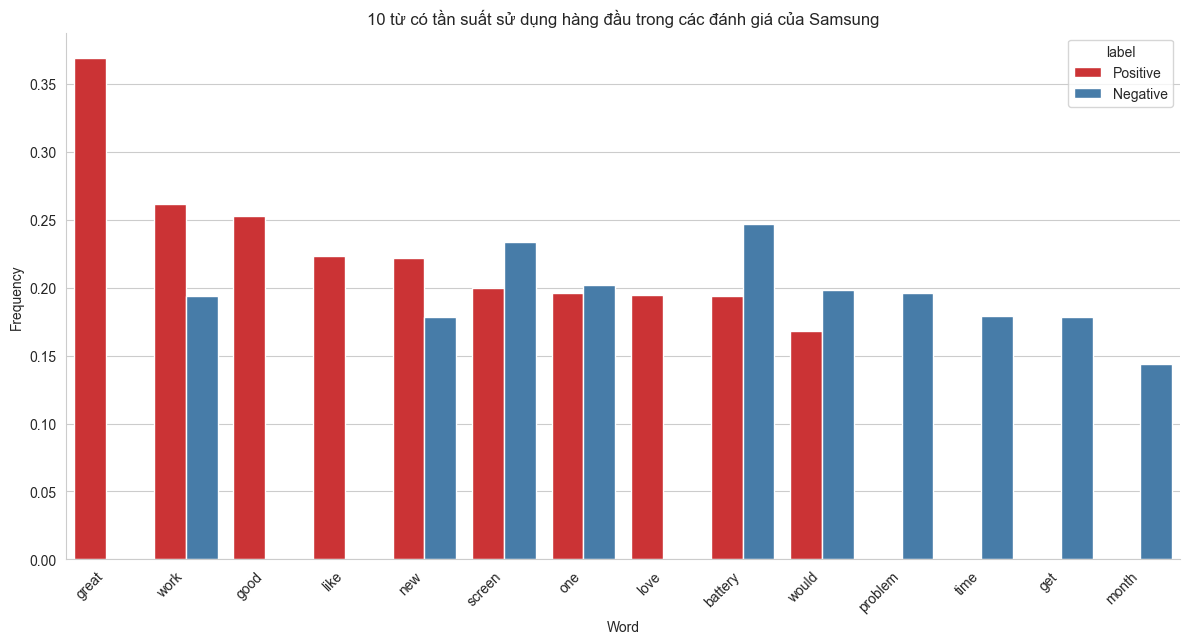

In [85]:
topn_wordfreq_bar_both(samsung_pos_dtm, samsung_neg_dtm, len(samsung_review_pos), len(samsung_review_neg), 10, "10 từ có tần suất sử dụng hàng đầu trong các đánh giá của Samsung", "Set1")

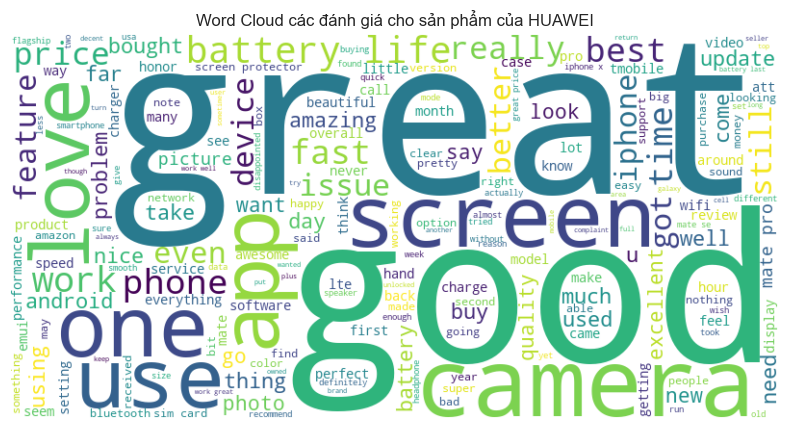

In [86]:
huawei_reviews = review_grouped.loc["HUAWEI", "clean_text"]
draw_wordcloud(huawei_reviews, "Word Cloud các đánh giá cho sản phẩm của HUAWEI")

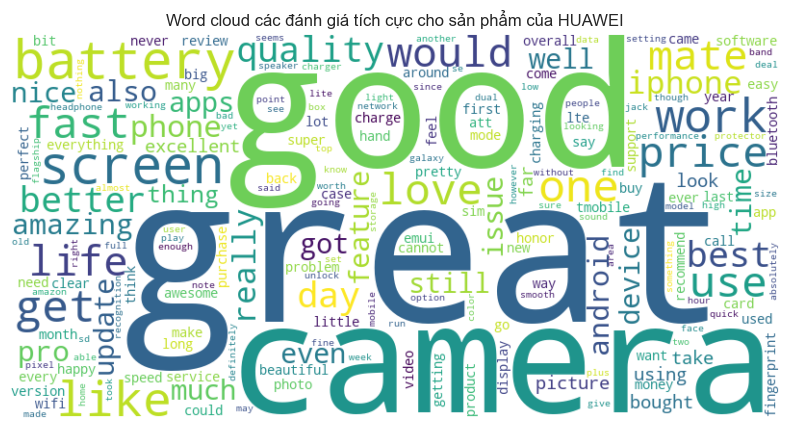

In [87]:
plot_wordcloud(huawei_pos_dtm, 'Word cloud các đánh giá tích cực cho sản phẩm của HUAWEI')

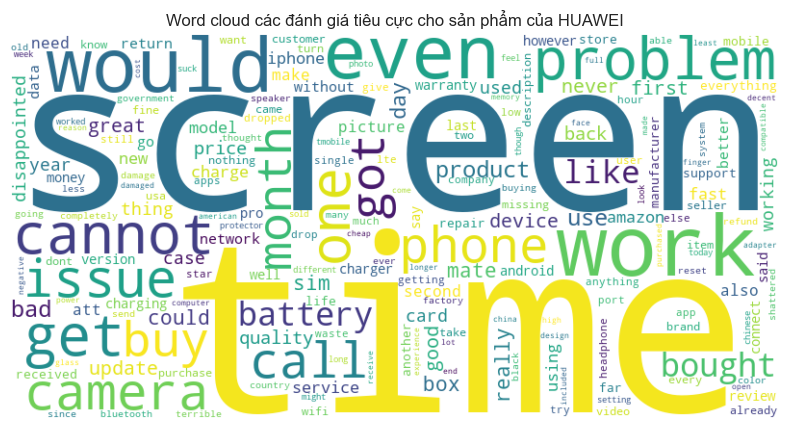

In [88]:
plot_wordcloud(huawei_neg_dtm, 'Word cloud các đánh giá tiêu cực cho sản phẩm của HUAWEI')

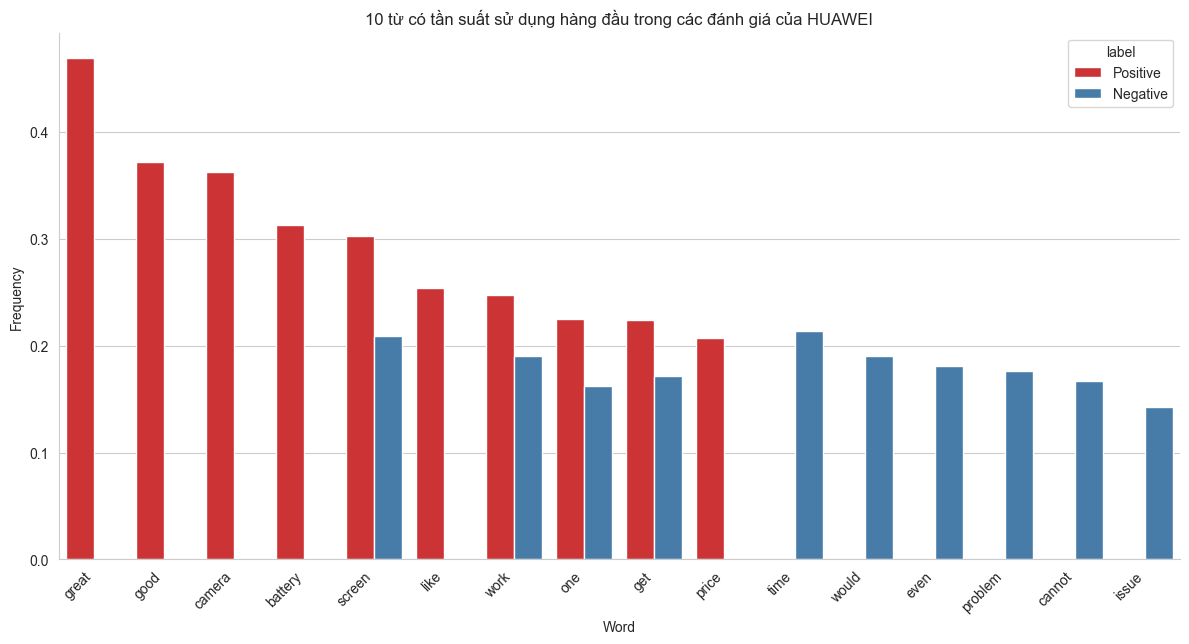

In [89]:
topn_wordfreq_bar_both(huawei_pos_dtm, huawei_neg_dtm, len(huawei_review_pos), len(huawei_review_neg), 10, "10 từ có tần suất sử dụng hàng đầu trong các đánh giá của HUAWEI", "Set1")

> 7:
- Apple: dòng sản phẩm "iphone" được nhắc đến nhiều nhất trong các đánh giá, tiếp đến là vấn đề về pin(battery), và hiệu năng (work).
- Samsung: vấn đề về sử dụng(use) và màn hình(screen) được nhắc đến nhiều nhất ở đây.
- HUAWEI: ngoài những từ ngữ khen ngợi như "great" và "good", vấn đề về màn hình(screen), máy ảnh(camera), pin(battery) và giá cả(price) là nhắc đến nhiều nhất.

> 8:
Ở Apple và Samsung thì "battery" đều xuất hiện ở các đánh giá tích cực và tiêu cực, đặc biệt ở tiêu cực còn có tần suất lớn hơn. Nhưng các sản phẩm của HUAWEI, từ khóa "battery" chỉ xuất hiện ở các đánh giá tích cực.
* Điều này có thể cho thấy rằng khách hàng đánh giá rất cao về chất lượng/tuổi thọ pin ở sản phẩm của HUAWEI.

>9:
- Apple: Trong những đánh giá tích cực xuất hiện phổ từ khóa "great" là điều khá dễ hiểu. Từ "work" thì có thể hiệu năng xuất làm việc của những sản phẩm này được đánh giá tốt. Còn về từ khóa "new", để hiểu thêm về nó ta đặt ra câu hỏi số 12.
- Samsung: Từ khóa "work" và "great" ở đây cũng tương tự như ở Apple.
- HUAWEI: ở đây ngoài những từ có ý nghĩa khen ngợi, có xuất hiện thêm các từu khóa như "camera, screen, battery" cho thấy khách hàng đánh giá cao về chất lượng linh kiện, tính năng của HUAWEI.

> 10: Nếu nói đến từ khóa xuất hiện nhiều ở đánh giá tiêu cực của cả 3 thương hiệu thì đó là từ "screen".

> 11: "battery" và "screen" là 2 từ khóa xuất hiện nhiều trong cả đánh giá tích cực và tiêu cực của cả 3 sản phẩm, đặc biệt là ở Apple và Samsung khi tần suất tiêu cực cao hơn tích cực. Cho thấy đây có thể là những vấn đề chung mà các nhà sản xuất cần lưu ý và cải thiện trong các sản phẩm mới.

***12. Từ khóa "new" ta đặt ra câu hỏi nó xuất hiện nhiều trên những sản phẩm nào của Apple? Qua đó có thể thấy được khách hàng có cái nhìn tích cực về vấn đề gì không?***


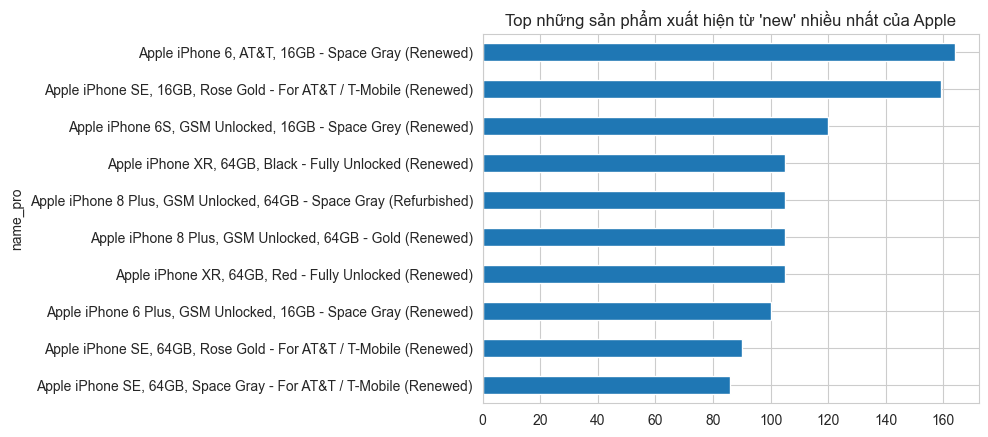

In [90]:
apple = reviews[reviews["brand"]=="Apple"]
apple[apple["clean_text"].apply(lambda x: "new" in x)]["name_pro"].value_counts().sort_values(ascending=True).tail(10).plot(kind="barh")
plt.title("Top những sản phẩm xuất hiện từ 'new' nhiều nhất của Apple")
plt.show()

In [91]:
apple_copy = apple.copy()
apple_copy["renewed"] = apple_copy["name_pro"].apply(lambda x: ("Renewed" in x) or ("Reburshied" in x))
renewed_percentage = (apple_copy["renewed"].sum() / len(apple_copy["renewed"])) * 100
print("{0:.1f}% sản phẩm được bán của Apple là renewed/reburshied.".format(renewed_percentage))


96.5% sản phẩm được bán của Apple là renewed/reburshied.


> 12: Khi đi sâu vào từ khóa "new", ta có thể thấy rằng khác hàng đánh giá cao những sản phẩm đã được làm mới lại (Renewed,Reburshied) trước khi bán, và có 96.5% sản phẩm của Apple được bán ở đây đã được tân trang, làm mới trước khi bán.

# Kết luận

---
Nhìn chung khách hàng có phần lớn có đánh giá tích cự đối với các sản phẩm điện thoại được bán trên Amazon. Hai thương hiệu phổ biến nhất là Samsung và Apple.
 Trong số tất cả các thương hiệu thì HUAWEI là được đánh giá cao nhất
 - Hơn 96% sản phẩm được bán của hãng Apple là những sản phẩm đã được tân trang và làm mới lại trước khi bán ra, người mua hài lòng với những sản phẩm này và sẽ đưa ra lời phàn nàn nếu như thấy các vấn đề liên quan đến màn hình và tuổi thọ pin.
 - Người mua Samsung nói chung hài lòng về sản phẩm đặc biệt khi nói đến hiệu năng. Tương tự Apple, khiếu nại của khách hàng cũng chủ yếu về màn hình và pin.
 - Đối với HUAWEI, thương hiệu được đánh giá cao nhất ở đây, người mua thể hiện sự đánh giá cao đặc biệt là ở máy ảnh, pin và giá cả. Một số khách hàng phàn nàn về màn hình và hiệu năng nhưng nó là không bao nhiêu so với những lời khen.


---
=> Qua phân tích tôi có đưa ra một vài khuyến nghị:
- Đối với Amazon và bên thứ ba(người bán): Nên tăng cường việc kiểm tra chất lượng và độ tin cậy của các sản phẩm đã được tân trang và làm mới lại trước khi bán ra. Nên cung cấp thông tin chi tiết và đáng tin cậy về sản phẩm, điểm mạnh và điểm yếu của sản phẩm, đặc biệt là các thông số kỹ thuật liên quan đến màn hình và pin, để khách hàng có thể đưa ra quyết định mua hàng chính xác hơn. Điều này có thể làm tăng những đánh giá tích cực, nâng cao lòng tin của khách hàng.
- Đối các thương hiệu/ hãng điện thoại: Nên tiếp tục tập trung vào việc cải thiện chất lượng màn hình, tuổi thọ pin, chất lượng camera và hiệu năng của sản phẩm. Vì đây là những vấn đề được quan tâm nhiều nhất trên chiếc điện thoại, đặc biệt là tuổi thọ pin. Điều này sẽ giúp làm tăng trải nghiệm người dùng, giảm những đánh giá tiêu cực từ khách hàng.